### Import

In [1]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

### Load

In [2]:
dataframe_penguins = sns.load_dataset('penguins')

### Preview

In [3]:
dataframe_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
dataframe_penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
# dataframe_penguins.select_dtypes(include='number').columns.values

In [6]:
dataframe_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], inplace=True)

In [7]:
dataframe_penguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

In [8]:
dataframe_penguins_numeric = dataframe_penguins.select_dtypes(include='number')
dataframe_penguins_numeric.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


### Preclustering

#### Features

##### _bin

bill_length_mm

In [9]:
ndigits = -1
dataframe_penguins['bill_length_mm_bin'] = round(dataframe_penguins['bill_length_mm'], ndigits=ndigits)

print(f"{dataframe_penguins['bill_length_mm'].head(3).values} \n{round(dataframe_penguins['bill_length_mm'], ndigits=ndigits).head(3).values}")
print(f"from {len(dataframe_penguins['bill_length_mm'].unique())} | to {len(dataframe_penguins['bill_length_mm_bin'].unique())}")
print(sorted(dataframe_penguins['bill_length_mm_bin'].unique()))

[39.1 39.5 40.3] 
[40. 40. 40.]
from 164 | to 4
[30.0, 40.0, 50.0, 60.0]


bill_depth_mm

In [10]:
ndigits = -1
dataframe_penguins['bill_depth_mm_bin'] = round(dataframe_penguins['bill_depth_mm'], ndigits=ndigits)

print(f"{dataframe_penguins['bill_depth_mm'].head(3).values} \n{round(dataframe_penguins['bill_depth_mm'], ndigits=ndigits).head(3).values}")
print(f"from {len(dataframe_penguins['bill_depth_mm'].unique())} | to {len(dataframe_penguins['bill_depth_mm_bin'].unique())}")
print(sorted(dataframe_penguins['bill_depth_mm_bin'].unique()))

[18.7 17.4 18. ] 
[20. 20. 20.]
from 80 | to 2
[10.0, 20.0]


flipper_length_mm

In [11]:
ndigits = -1
dataframe_penguins['flipper_length_mm_bin'] = round(dataframe_penguins['flipper_length_mm'], ndigits=ndigits)

print(f"{dataframe_penguins['flipper_length_mm'].head(3).values} \n{round(dataframe_penguins['flipper_length_mm'], ndigits=ndigits).head(3).values}")
print(f"from {len(dataframe_penguins['flipper_length_mm'].unique())} | to {len(dataframe_penguins['flipper_length_mm_bin'].unique())}")
print(sorted(dataframe_penguins['flipper_length_mm_bin'].unique()))

[181. 186. 195.] 
[180. 190. 200.]
from 55 | to 7
[170.0, 180.0, 190.0, 200.0, 210.0, 220.0, 230.0]


body_mass_g

In [12]:
ndigits = -3
dataframe_penguins['body_mass_g_bin'] = round(dataframe_penguins['body_mass_g'], ndigits=ndigits)

print(f"{dataframe_penguins['body_mass_g'].head(3).values} \n{round(dataframe_penguins['body_mass_g'], ndigits=ndigits).head(3).values}")
print(f"from {len(dataframe_penguins['body_mass_g'].unique())} | to {len(dataframe_penguins['body_mass_g_bin'].unique())}")
print(sorted(dataframe_penguins['body_mass_g_bin'].unique()))

[3750. 3800. 3250.] 
[4000. 4000. 3000.]
from 94 | to 4
[3000.0, 4000.0, 5000.0, 6000.0]


##### _mean

In [13]:
dataframe_penguins[['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean']] = dataframe_penguins.groupby(by=['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin'])[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].transform('mean')

#### Preclustering

##### _bin

In [14]:
dataframe_penguins['cluster_bin'] = (
    dataframe_penguins['bill_length_mm_bin'].astype(str) + '_' + 
    dataframe_penguins['bill_depth_mm_bin'].astype(str) + '_' + 
    dataframe_penguins['flipper_length_mm_bin'].astype(str) + '_' + 
    dataframe_penguins['body_mass_g_bin'].astype(str)
)

len(dataframe_penguins['cluster_bin'].unique())

46

In [15]:
# sns.pairplot(dataframe_penguins, hue='cluster_bin')

##### _mean

In [16]:
dataframe_penguins['cluster_mean'] = (
    dataframe_penguins['bill_length_mm_bin_mean'].astype(str) + '_' + 
    dataframe_penguins['bill_depth_mm_bin_mean'].astype(str) + '_' + 
    dataframe_penguins['flipper_length_mm_bin_mean'].astype(str) + '_' + 
    dataframe_penguins['body_mass_g_bin_mean'].astype(str)
)

len(dataframe_penguins['cluster_mean'].unique())

46

In [17]:
# sns.pairplot(dataframe_penguins, hue='cluster_mean')

### K-means #1 | mean

- Utiliza a média das variáveis ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g') referente aos grupos criados no preclustring.
- K-means aplicado a uma amostra.

#### Sample

In [18]:
dataframe_penguins_numeric_discrete_data = dataframe_penguins.drop_duplicates(subset=['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean'])[['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean']]

#### K-means

In [19]:
kmeans = KMeans(n_clusters=3, max_iter=600, n_init='auto', algorithm='lloyd')
kmeans.fit(dataframe_penguins_numeric_discrete_data)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(max_iter=600, n_clusters=3, n_init='auto')

#### Cluster assign

In [20]:
dataframe_penguins_numeric_discrete_data['cluster_discrete_by_mean'] = kmeans.labels_.astype('str')

In [21]:
# dataframe_penguins_numeric_discrete_data

#### Assign sample cluster to data

In [22]:
dataframe_penguins = dataframe_penguins.merge(right=dataframe_penguins_numeric_discrete_data[['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean', 'cluster_discrete_by_mean']], on=['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean'], how='left')

In [23]:
# dataframe_penguins

#### Graph

In [24]:
dataframe_penguins_numeric_kmeans1 = dataframe_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'cluster_discrete_by_mean']]

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

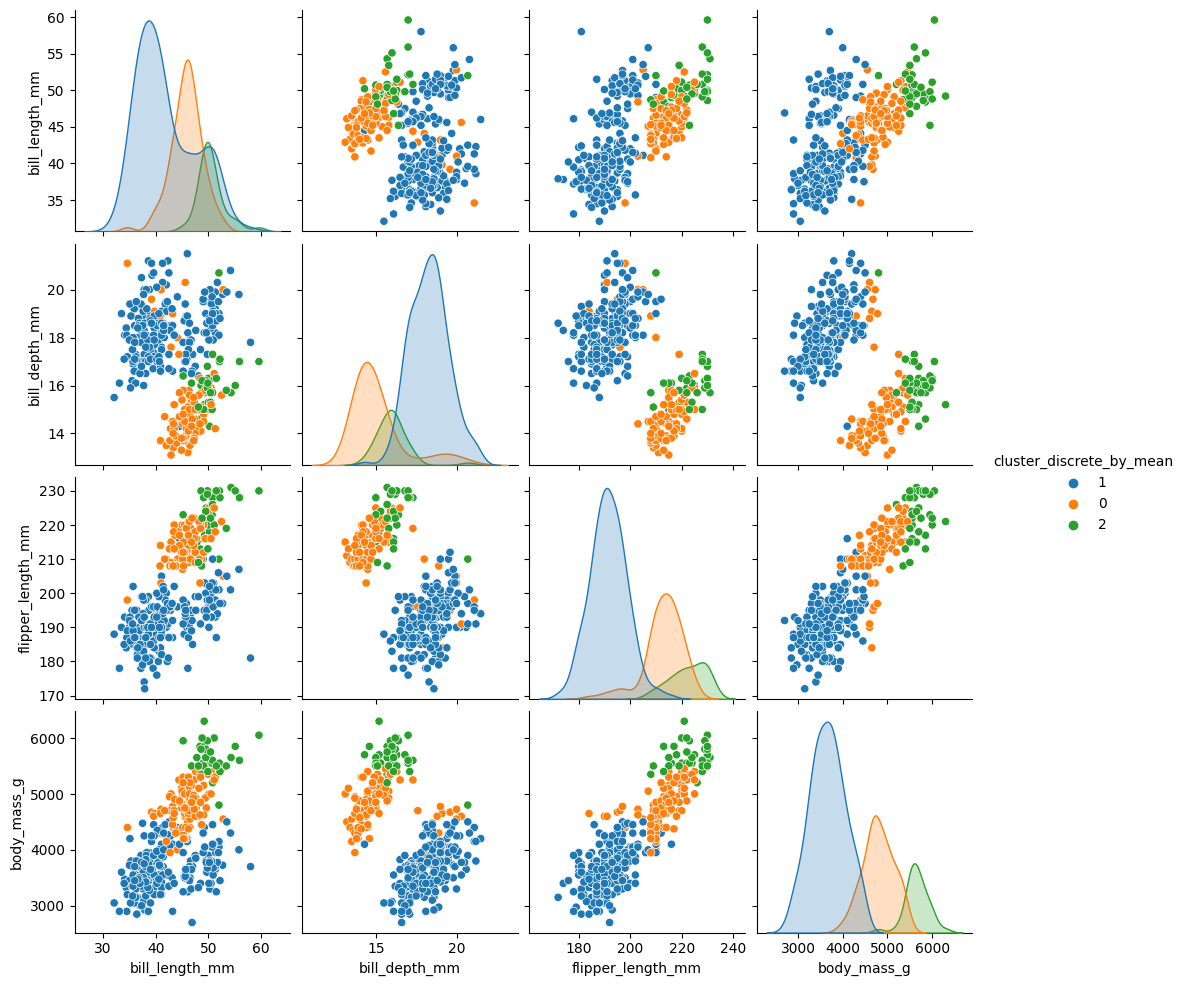

In [25]:
sns.pairplot(dataframe_penguins_numeric_kmeans1, hue='cluster_discrete_by_mean')

In [26]:
pd.crosstab(dataframe_penguins['species'], dataframe_penguins['cluster_discrete_by_mean'])

cluster_discrete_by_mean,0,1,2
species,,,
Adelie,10,141,0
Chinstrap,1,66,1
Gentoo,85,1,37


### K-means #2 | bin

- Utiliza os valores arredondados (bins) das variáveis ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g') referente aos grupos criados no preclustring.
- K-means aplicado a uma amostra.

#### Sample

In [27]:
dataframe_penguins_numeric_discrete_data = dataframe_penguins.drop_duplicates(subset=['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin'])[['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin']]

#### K-means

In [28]:
kmeans = KMeans(n_clusters=3, max_iter=600, n_init='auto', algorithm='lloyd')
kmeans.fit(dataframe_penguins_numeric_discrete_data)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(max_iter=600, n_clusters=3, n_init='auto')

#### Cluster assign

In [29]:
dataframe_penguins_numeric_discrete_data['cluster_discrete_by_bin'] = kmeans.labels_.astype('str')

In [30]:
dataframe_penguins_numeric_discrete_data

,bill_length_mm_bin,bill_depth_mm_bin,flipper_length_mm_bin,body_mass_g_bin,cluster_discrete_by_bin
0,40.0,20.0,180.0,4000.0,1
1,40.0,20.0,190.0,4000.0,1
2,40.0,20.0,200.0,3000.0,1
3,40.0,20.0,190.0,3000.0,1
6,40.0,20.0,200.0,5000.0,2
7,30.0,20.0,190.0,3000.0,1
11,40.0,20.0,180.0,3000.0,1
13,30.0,20.0,200.0,4000.0,1
16,40.0,20.0,200.0,4000.0,1
17,30.0,20.0,180.0,3000.0,1


#### Assign sample cluster to data

In [31]:
dataframe_penguins = dataframe_penguins.merge(right=dataframe_penguins_numeric_discrete_data[['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin', 'cluster_discrete_by_bin']], on=['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin'], how='left')

#### Graph

In [32]:
dataframe_penguins_numeric_kmeans2 = dataframe_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'cluster_discrete_by_bin']]

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

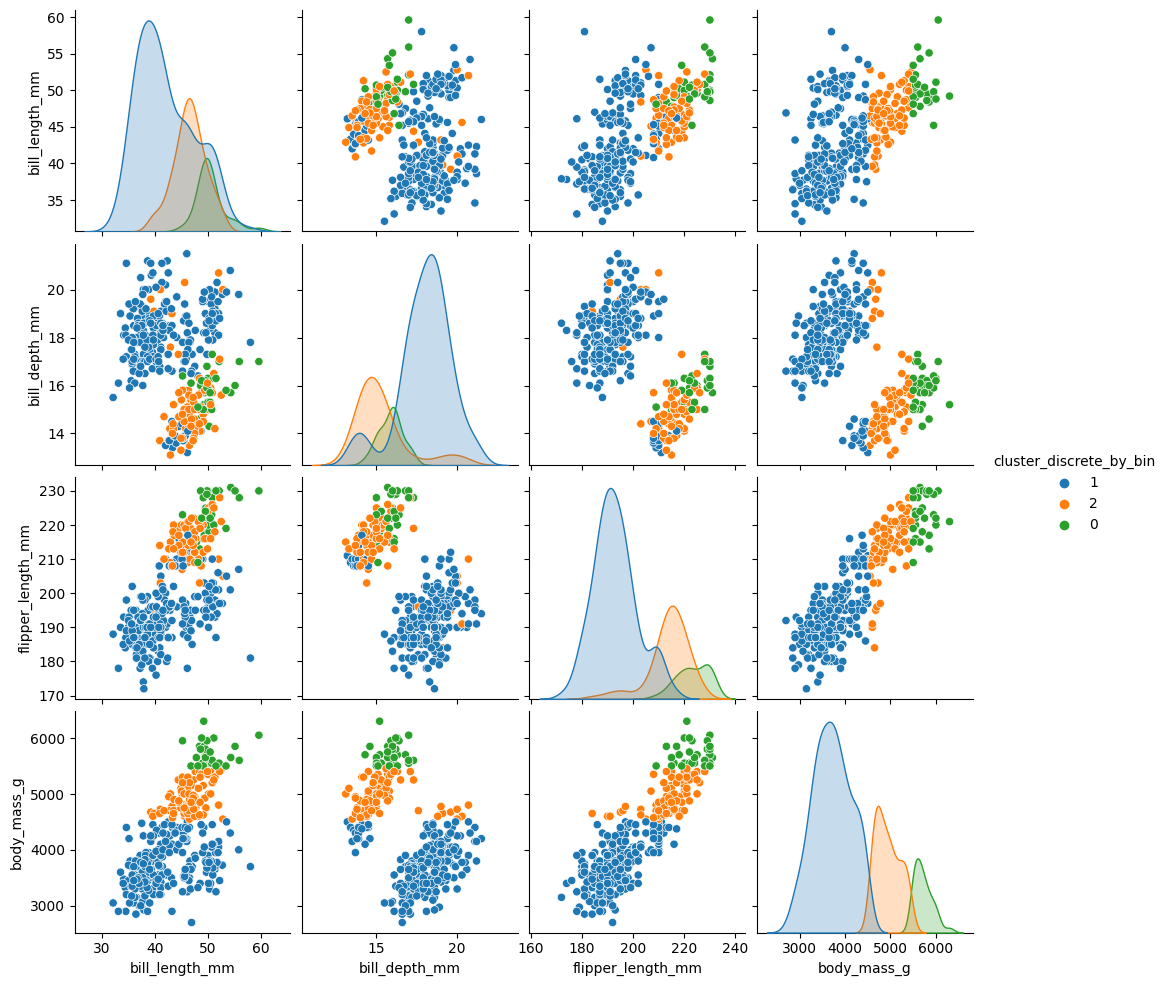

In [33]:
sns.pairplot(dataframe_penguins_numeric_kmeans2, hue='cluster_discrete_by_bin')

In [34]:
pd.crosstab(dataframe_penguins['species'], dataframe_penguins['cluster_discrete_by_bin'])

cluster_discrete_by_bin,0,1,2
species,,,
Adelie,0,144,7
Chinstrap,0,66,2
Gentoo,33,17,73


### K-means #3 | mean scaled

- Utiliza a média das variáveis redimensionadas ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g') referente aos grupos criados no preclustring.
- K-means aplicado a uma amostra.

#### Sample

In [35]:
dataframe_penguins_numeric_discrete_data = dataframe_penguins.drop_duplicates(subset=['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean'])[['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean']]

#### Data scaling

In [36]:
scaler = StandardScaler()
# scaler = MinMaxScaler()

dataframe_penguins_numeric_discrete_data_scaled = scaler.fit_transform(dataframe_penguins_numeric_discrete_data)

#### Elbow method

In [37]:
ssd = []
n_clusters = range(1, 15)

for n_clusters_ in n_clusters:
    kmeans = KMeans(n_clusters=n_clusters_, max_iter=600, n_init='auto', algorithm='lloyd')
    kmeans = kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)
    ssd.append(kmeans.inertia_)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is k

<Axes: xlabel='n_clusters'>

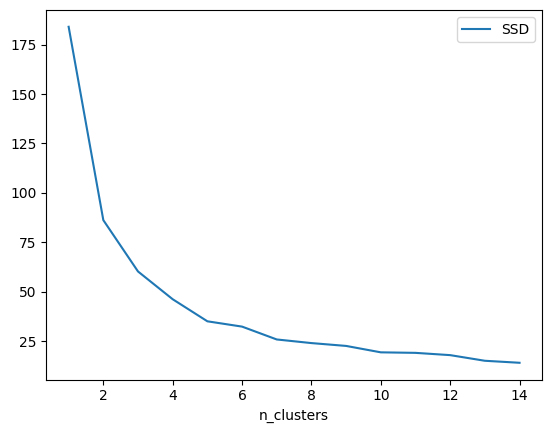

In [38]:
elbow_dataframe = pd.DataFrame({'n_clusters': list(range(1, len(ssd) + 1)), 'SSD': ssd})
elbow_dataframe.plot(x = 'n_clusters', y = 'SSD')

#### Silhouette coefficient

In [39]:
silhouettes = []
max_clusters = 15
n_clusters = range(2, max_clusters + 1)

for n_clusters_ in n_clusters:
    kmeans = KMeans(n_clusters=n_clusters_, max_iter=600, n_init='auto', algorithm='lloyd')
    kmeans = kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)

    silhouette_coefficient = silhouette_score(dataframe_penguins_numeric_discrete_data_scaled, kmeans.labels_)
    silhouettes.append(silhouette_coefficient)

    cluster_names = [f'cluster_{cluster}' for cluster in range(n_clusters_)]
    dataframe_penguins_numeric_discrete_data[f'clusters_{n_clusters_}'] = pd.Categorical.from_codes(kmeans.labels_, categories=cluster_names)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is k

<Axes: xlabel='number_clusters'>

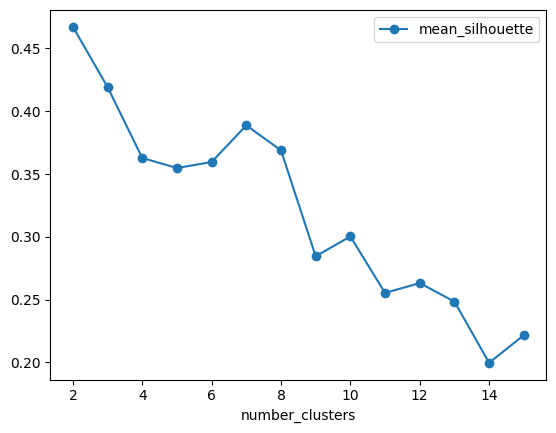

In [40]:
silhouette_dataframe = pd.DataFrame({'number_clusters': list(n_clusters), 'mean_silhouette': silhouettes})
silhouette_dataframe.plot.line(x = 'number_clusters', y = 'mean_silhouette', marker='o')

#### K-means

In [41]:
kmeans = KMeans(n_clusters=3, max_iter=600, n_init='auto', algorithm='lloyd')
kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(max_iter=600, n_clusters=3, n_init='auto')

#### Cluster assign

In [42]:
dataframe_penguins_numeric_discrete_data['cluster_discrete_by_mean_scaled'] = kmeans.labels_.astype('str')

In [43]:
# dataframe_penguins_numeric_discrete_data

#### Assign sample cluster to data

In [44]:
dataframe_penguins = dataframe_penguins.merge(right=dataframe_penguins_numeric_discrete_data[['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean', 'cluster_discrete_by_mean_scaled']], on=['bill_length_mm_bin_mean', 'bill_depth_mm_bin_mean', 'flipper_length_mm_bin_mean', 'body_mass_g_bin_mean'], how='left')

#### Graph

In [45]:
dataframe_penguins_numeric_kmeans3 = dataframe_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'cluster_discrete_by_mean_scaled']]

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

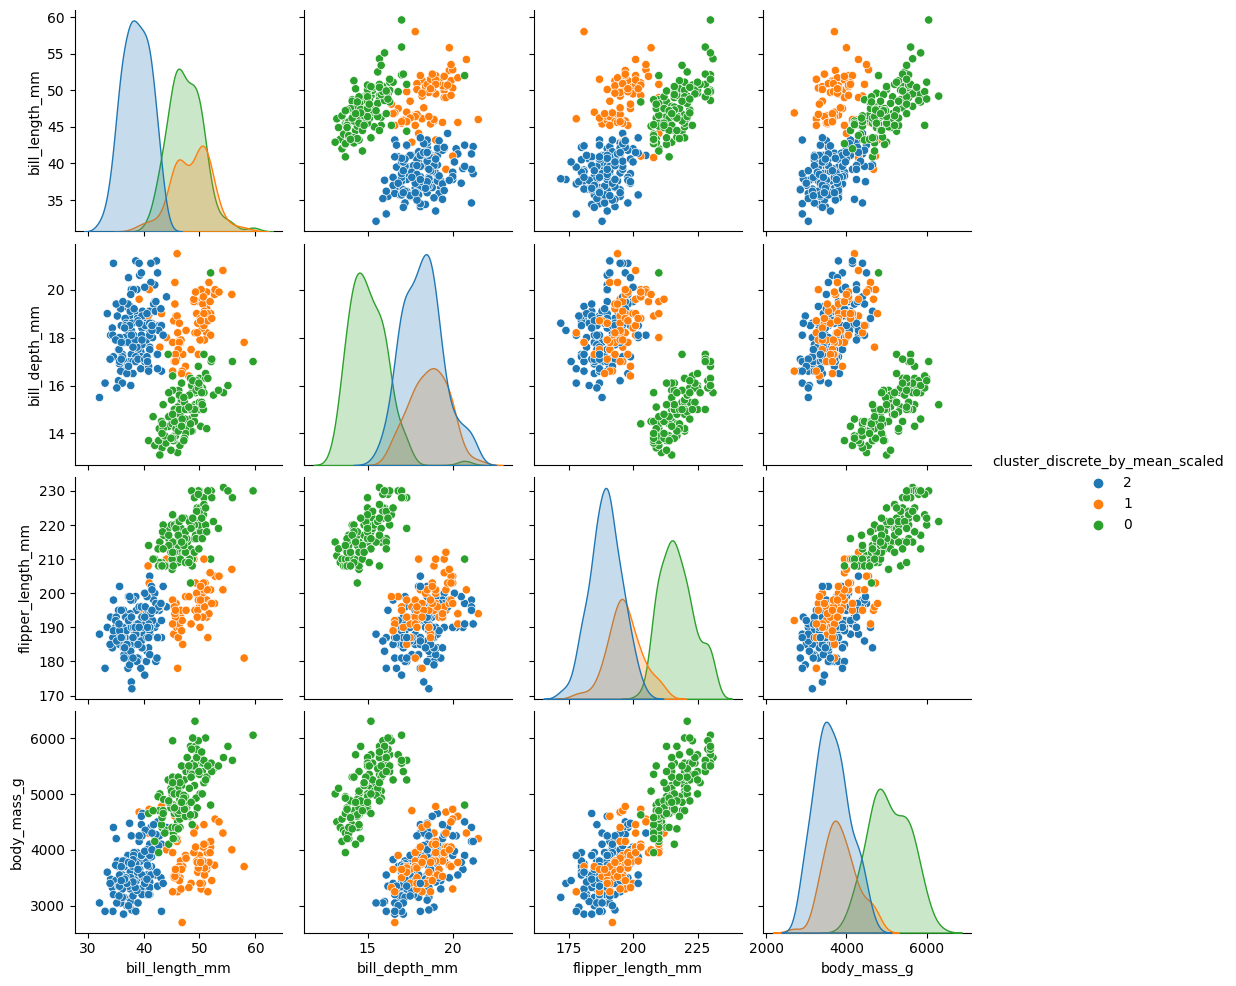

In [46]:
sns.pairplot(dataframe_penguins_numeric_kmeans3, hue='cluster_discrete_by_mean_scaled')

In [47]:
pd.crosstab(dataframe_penguins['species'], dataframe_penguins['cluster_discrete_by_mean_scaled'])

cluster_discrete_by_mean_scaled,0,1,2
species,,,
Adelie,0,9,142
Chinstrap,1,61,6
Gentoo,123,0,0


### K-means #4 | bin scaled

- Utiliza os valores arredondados (bins) das variáveis redimensionados ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g') referente aos grupos criados no preclustring.
- K-means aplicado a uma amostra.

#### Sample

In [48]:
dataframe_penguins_numeric_discrete_data = dataframe_penguins.drop_duplicates(subset=['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin'])[['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin']]

#### Data scaling

In [49]:
# scaler = StandardScaler()
scaler = MinMaxScaler()

dataframe_penguins_numeric_discrete_data_scaled = scaler.fit_transform(dataframe_penguins_numeric_discrete_data)

#### Elbow method

In [50]:
ssd = []
n_clusters = range(1, 15)

for n_clusters_ in n_clusters:
    kmeans = KMeans(n_clusters=n_clusters_, max_iter=600, n_init='auto', algorithm='lloyd')
    kmeans = kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)
    ssd.append(kmeans.inertia_)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is k

<Axes: xlabel='n_clusters'>

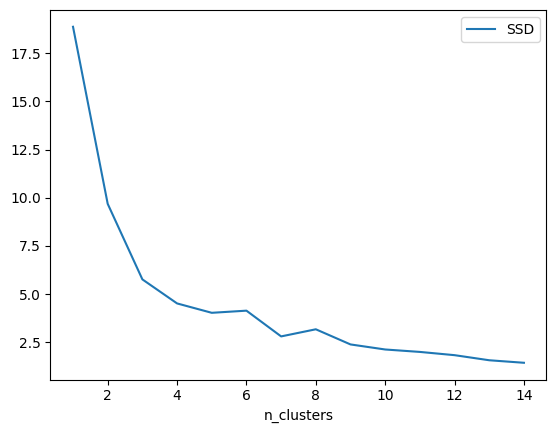

In [51]:
elbow_dataframe = pd.DataFrame({'n_clusters': list(range(1, len(ssd) + 1)), 'SSD': ssd})
elbow_dataframe.plot(x = 'n_clusters', y = 'SSD')

#### Silhouette coefficient

In [52]:
silhouettes = []
max_clusters = 15
n_clusters = range(2, max_clusters + 1)

for n_clusters_ in n_clusters:
    kmeans = KMeans(n_clusters=n_clusters_, max_iter=600, n_init='auto', algorithm='lloyd')
    kmeans = kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)

    silhouette_coefficient = silhouette_score(dataframe_penguins_numeric_discrete_data_scaled, kmeans.labels_)
    silhouettes.append(silhouette_coefficient)

    cluster_names = [f'cluster_{cluster}' for cluster in range(n_clusters_)]
    dataframe_penguins_numeric_discrete_data[f'clusters_{n_clusters_}'] = pd.Categorical.from_codes(kmeans.labels_, categories=cluster_names)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is k

<Axes: xlabel='number_clusters'>

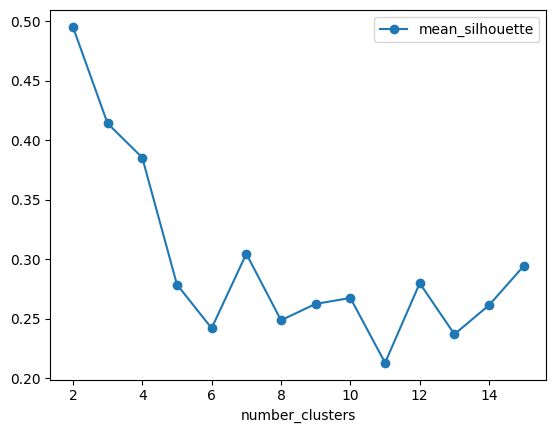

In [53]:
silhouette_dataframe = pd.DataFrame({'number_clusters': list(n_clusters), 'mean_silhouette': silhouettes})
silhouette_dataframe.plot.line(x = 'number_clusters', y = 'mean_silhouette', marker='o')

#### K-means

In [54]:
kmeans = KMeans(n_clusters=3, max_iter=600, n_init='auto', algorithm='lloyd')
kmeans.fit(dataframe_penguins_numeric_discrete_data_scaled)

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(max_iter=600, n_clusters=3, n_init='auto')

#### Cluster assign

In [55]:
dataframe_penguins_numeric_discrete_data['cluster_discrete_by_bin_scaled'] = kmeans.labels_.astype('str')

In [56]:
dataframe_penguins_numeric_discrete_data

,bill_length_mm_bin,bill_depth_mm_bin,flipper_length_mm_bin,body_mass_g_bin,clusters_2,clusters_3,clusters_4,clusters_5,clusters_6,clusters_7,clusters_8,clusters_9,clusters_10,clusters_11,clusters_12,clusters_13,clusters_14,clusters_15,cluster_discrete_by_bin_scaled
0,40.0,20.0,180.0,4000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_0,cluster_1,cluster_5,cluster_4,cluster_5,cluster_3,cluster_8,cluster_0,cluster_2,cluster_7,0
1,40.0,20.0,190.0,4000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_0,cluster_3,cluster_0,cluster_4,cluster_5,cluster_7,cluster_8,cluster_0,cluster_2,cluster_7,0
2,40.0,20.0,200.0,3000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_3,cluster_1,cluster_0,cluster_4,cluster_1,cluster_10,cluster_5,cluster_5,cluster_4,cluster_0,0
3,40.0,20.0,190.0,3000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_3,cluster_1,cluster_5,cluster_2,cluster_1,cluster_10,cluster_5,cluster_5,cluster_7,cluster_13,0
6,40.0,20.0,200.0,5000.0,cluster_1,cluster_2,cluster_0,cluster_1,cluster_0,cluster_3,cluster_6,cluster_1,cluster_7,cluster_1,cluster_3,cluster_8,cluster_10,cluster_11,2
7,30.0,20.0,190.0,3000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_3,cluster_5,cluster_5,cluster_8,cluster_1,cluster_3,cluster_9,cluster_11,cluster_7,cluster_5,0
11,40.0,20.0,180.0,3000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_3,cluster_1,cluster_5,cluster_2,cluster_1,cluster_3,cluster_5,cluster_5,cluster_7,cluster_13,0
13,30.0,20.0,200.0,4000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_0,cluster_5,cluster_0,cluster_4,cluster_5,cluster_7,cluster_4,cluster_11,cluster_13,cluster_14,0
16,40.0,20.0,200.0,4000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_0,cluster_3,cluster_0,cluster_4,cluster_5,cluster_7,cluster_4,cluster_0,cluster_6,cluster_0,0
17,30.0,20.0,180.0,3000.0,cluster_1,cluster_0,cluster_1,cluster_0,cluster_3,cluster_5,cluster_5,cluster_8,cluster_1,cluster_3,cluster_9,cluster_5,cluster_7,cluster_5,0


#### Assign sample cluster to data

In [57]:
dataframe_penguins = dataframe_penguins.merge(right=dataframe_penguins_numeric_discrete_data[['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin', 'cluster_discrete_by_bin_scaled']], on=['bill_length_mm_bin', 'bill_depth_mm_bin', 'flipper_length_mm_bin', 'body_mass_g_bin'], how='left')

#### Graph

In [58]:
dataframe_penguins_numeric_kmeans4 = dataframe_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'cluster_discrete_by_bin_scaled']]

c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rafael_doepfer\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

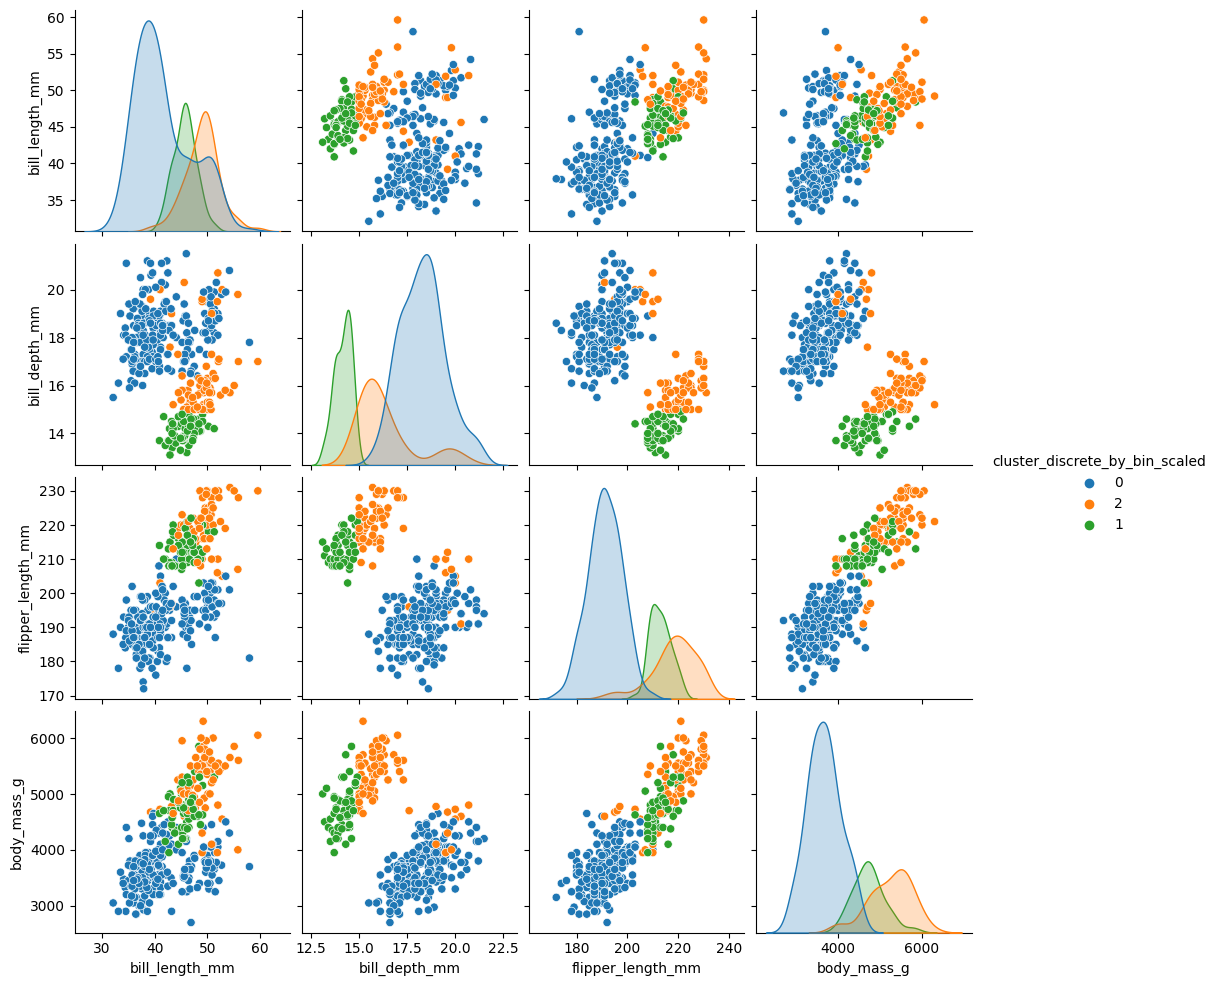

In [59]:
sns.pairplot(dataframe_penguins_numeric_kmeans4, hue='cluster_discrete_by_bin_scaled')

In [60]:
pd.crosstab(dataframe_penguins['species'], dataframe_penguins['cluster_discrete_by_bin_scaled'])

cluster_discrete_by_bin_scaled,0,1,2
species,,,
Adelie,146,0,5
Chinstrap,61,0,7
Gentoo,0,60,63
